# Test Classificatori su Dati Reali

Valutazione delle tre configurazioni di addestramento del classificatore **ResNet-50** sul test set reale:

| Configurazione | Dati di Training |
|---|---|
| **Baseline** | Solo immagini reali |
| **Real+Synth** | Immagini reali + sintetiche |
| **Full Synth** | Solo immagini sintetiche |


#### Verifica dell'ambiente di lavoro

Viene calcolato il percorso base sulla base dell'ambiente di lavoro utilizzato (Locale o Google Colab)

In [48]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.


Ambiente locale rilevato.
Percorso base: ../


#### Import librerie


In [49]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score, f1_score
)

#### Configurazione

In [50]:
# Definizione percorsi degli esperimenti
BASELINE_EXP_DIR   = os.path.join(BASE_PATH, 'experiments', 'classifiers/resnet50/01a_real_only')
REAL_SYNTH_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/resnet50/01b_real_synth_partial')
FULL_SYNTH_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/resnet50/01d_synthetic_only')

# Drive ID dei modelli salvati in Google Drive
BASELINE_MODEL_DRIVE_ID   = '1v1-eXa-pFi5MHUWY0Dpd7bWqzPXiIk5P'

REAL_SYNTH_MODEL_DRIVE_ID = '11f9pcL8kbLz7hi6i3lqDuferljdRl2uV'

FULL_SYNTH_MODEL_DRIVE_ID = '1375PxM0PeeKIczXA0ZKL7nWegQ-Xb7J7'

# Drive ID dei JSON contenenti le metriche calcolate sul validation set
BASELINE_METRICS_DRIVE_ID   = '1v7bfGdycvXcxyIVpSF5x2--943apw2KE'

REAL_SYNTH_METRICS_DRIVE_ID = '1J55coTQluAadvUsusaR2uzP5juNCYnKx'

FULL_SYNTH_METRICS_DRIVE_ID = '1ayDuA8MMY6u2Uz1BIB0IQdUVnO1fB69D'

# Definizione del Dataset di test
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
TEST_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'test.csv')

# Preprocessing
IMG_SIZE = (224, 224) # Dimensione standard ResNet-50
BATCH_SIZE = 16
SEED = 42
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# Definizione cartelle di output (output risultati, figure, tabelle e predizioni)
OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'classifiers/resnet50/01y_test')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')

for dir in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR):
    os.makedirs(dir, exist_ok=True)

print(f"Output salvato in: {OUTPUT_DIR}")
print(f"  figures/     => {FIGURES_DIR}")
print(f"  tables/      => {TABLES_DIR}")
print(f"  predictions/ => {PREDICTIONS_DIR}")

Output salvato in: ../results/09_test_classificatori
  figures/     => ../results/09_test_classificatori/figures
  tables/      => ../results/09_test_classificatori/tables
  predictions/ => ../results/09_test_classificatori/predictions


#### Verifica e download dataset preprocessato

Scarica da Google Drive il dataset reale preprocessato (immagini + CSV),
se non già presente in locale.

- Controllo presenza: verifica che esistano entrambi i CSV (`train.csv`, `val.csv`)
e che la prima immagine referenziata sia effettivamente sul disco.
Se il controllo passa, il download viene saltato.

- Se assente: scarica lo ZIP, lo estrae in `data/processed/` e rimuove l'archivio

In [51]:
# Percorso dello zip del dataset preprocessato
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def verifica_processed_data():
    if not os.path.isfile(TEST_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TEST_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not verifica_processed_data():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print("Dataset estratto")
else:
    print("Dataset già presente, salto il download")


Dataset già presente, salto il download


#### Creazione Dataset di Test

Utilizzo del file `test.csv` del dataset preprocessato, che contiene le immagini mai viste durante il training né la validazione. Non viene utilizzata augmentation, solo preprocessing identico a quello utilizzato in training.

In [52]:
df_test = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_test['processed_path'] = df_test['processed_path'].apply(fix_path)

n_positivi = (df_test['cancer'] == 1).sum()
n_negativi = (df_test['cancer'] == 0).sum()
print(f"Test set: {len(df_test)} immagini  (cancer=1: {n_positivi}, cancer=0: {n_negativi})")

def caricamento_preprocessing(percorso, etichetta):
    img_real = tf.io.read_file(percorso)
    img = tf.image.decode_image(img_real, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, tf.cast(etichetta, tf.float32)

def crea_dataset_test(df):
    percorsi  = df['processed_path'].tolist()    
    etichette = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((percorsi, etichette))
    ds = ds.map(lambda p, l: caricamento_preprocessing(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = crea_dataset_test(df_test)
print("Dataset di test pronto")

Test set: 438 immagini  (cancer=1: 73, cancer=0: 365)
Dataset di test pronto


#### Caricamento Modelli

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../`)
2. Cartella `results/test_classificatori/models/` (se scaricati in precedenza)
3. Download da Google Drive → salvato in `results/test_classificatori/models/`

In [53]:
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

MODELS_CONFIG = {
    'Baseline': {
        'percorso_exp':   os.path.join(BASELINE_EXP_DIR,   'baseline_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'baseline_resnet50_final_best.keras'),
        'drive_id':   BASELINE_MODEL_DRIVE_ID,
    },
    'Real+Synth': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'real_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'real_synth_resnet50_final_best.keras'),
        'drive_id':   REAL_SYNTH_MODEL_DRIVE_ID,
    },
    'Full_Synth': {
        'percorso_exp':   os.path.join(FULL_SYNTH_EXP_DIR, 'full_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'full_synth_resnet50_final_best.keras'),
        'drive_id':   FULL_SYNTH_MODEL_DRIVE_ID,
    },
}

def caricamento_classificatore(nome_conf, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome_conf}] Carico dalla cartella esperimento")
        return keras.models.load_model(config['percorso_exp'])

    # Cache in results/models/
    if os.path.isfile(config['percorso_modello']):
        print(f"[{nome_conf}] Carico dalla cartella models")
        return keras.models.load_model(config['percorso_modello'])

    # Download da Drive
    print(f"[{nome_conf}] Modello non trovato localmente, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_modello'], quiet=False)
    print(f"[{nome_conf}] Salvato in: {config['percorso_modello']}")
    return keras.models.load_model(config['percorso_modello'])

baseline_model   = caricamento_classificatore('Baseline',   MODELS_CONFIG['Baseline'])
real_synth_model = caricamento_classificatore('Real+Synth', MODELS_CONFIG['Real+Synth'])
full_synth_model = caricamento_classificatore('Full Synth', MODELS_CONFIG['Full_Synth'])

print("\nTutti i modelli caricati.")

[Baseline] Carico dalla cartella esperimento


[Real+Synth] Carico dalla cartella esperimento
[Full Synth] Carico dalla cartella esperimento

Tutti i modelli caricati.


#### Caricamento Soglie Ottimali dal Validation Set

Le soglie ottimali (indice di Youden: J = TPR − FPR) sono state salvate in `val_metrics.json` durante il training.
Vengono utilizzate quelle per non essere ricalcolate sul set di test

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../val_metrics.json`)
2. Cache in `results/test_classificatori/val_metrics/`
3. Download da Google Drive → salvato nella cartella val_metrics

In [54]:
VAL_METRICS_DIR = os.path.join(OUTPUT_DIR, 'val_metrics')
os.makedirs(VAL_METRICS_DIR, exist_ok=True)

METRICS_CONFIG = {
    'Baseline': {
        'percorso_exp':   os.path.join(BASELINE_EXP_DIR,   'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'baseline_val_metrics.json'),
        'drive_id':   BASELINE_METRICS_DRIVE_ID,
    },
    'Real+Synth': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'real_synth_val_metrics.json'),
        'drive_id':   REAL_SYNTH_METRICS_DRIVE_ID,
    },
    'Full_Synth': {
        'percorso_exp':   os.path.join(FULL_SYNTH_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'full_synth_val_metrics.json'),
        'drive_id':   FULL_SYNTH_METRICS_DRIVE_ID,
    },
}

def load_val_metrics(nome, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome}] Carico val_metrics dalla cartella esperimento")
        with open(config['percorso_exp']) as f:
            return json.load(f)

    # Cache in results/val_metrics/
    if os.path.isfile(config['percorso_metriche']):
        print(f"[{nome}] Carico val_metrics dalla cartella metriche")
        with open(config['percorso_metriche']) as f:
            return json.load(f)

    # Download da Drive
    print(f"[{nome}] val_metrics.json non trovato, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_metriche'], quiet=False)
    print(f"[{nome}] Salvato in: {config['percorso_metriche']}")
    with open(config['percorso_metriche']) as f:
        return json.load(f)

metriche_baseline   = load_val_metrics('Baseline',   METRICS_CONFIG['Baseline'])
metriche_real_synth = load_val_metrics('Real+Synth', METRICS_CONFIG['Real+Synth'])
metriche_full_synth = load_val_metrics('Full Synth', METRICS_CONFIG['Full_Synth'])

baseline_threshold   = metriche_baseline['optimal_threshold_youden']
real_synth_threshold = metriche_real_synth['optimal_threshold_youden']
full_synth_threshold = metriche_full_synth['optimal_threshold_youden']

print("\nSoglie ottimali (dal validation set):")
print(f"  Baseline:    {baseline_threshold:.3f}")
print(f"  Real+Synth:  {real_synth_threshold:.3f}")
print(f"  Full Synth:  {full_synth_threshold:.3f}")

[Baseline] Carico val_metrics dalla cartella esperimento
[Real+Synth] Carico val_metrics dalla cartella esperimento
[Full Synth] Carico val_metrics dalla cartella esperimento

Soglie ottimali (dal validation set):
  Baseline:    0.446
  Real+Synth:  0.269
  Full Synth:  0.537


#### Predizioni sul Test Set

Raccolta delle probabilità predette da ciascun modello su tutti i batch del test set

In [55]:
def predizioni_test_set(modello, dataset):
    y_true_list, y_prob_list = [], []
    for imgs, labels in dataset:
        probs = modello.predict(imgs, verbose=0)
        y_prob_list.extend(probs.flatten())
        y_true_list.extend(labels.numpy())
    return np.array(y_true_list), np.array(y_prob_list)

print("Predizioni Baseline...")
y_true, baseline_probs   = predizioni_test_set(baseline_model,   test_ds)
print("Predizioni Real+Synth...")
_,      real_synth_probs = predizioni_test_set(real_synth_model, test_ds)
print("Predizioni Full Synth...")
_,      full_synth_probs = predizioni_test_set(full_synth_model, test_ds)
print("Predizioni completate")

Predizioni Baseline...
Predizioni Real+Synth...
Predizioni Full Synth...
Predizioni completate


#### Salvataggio Predizioni

Le probabilità predette e le etichette binarie (applicando le soglie ottimali del validation set) vengono salvate in CSV per analisi successive

In [56]:
df_predizioni = df_test[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})

df_predizioni['prob_baseline']   = baseline_probs
df_predizioni['prob_real_synth'] = real_synth_probs
df_predizioni['prob_full_synth'] = full_synth_probs

df_predizioni['pred_baseline']   = (baseline_probs   >= baseline_threshold).astype(int)
df_predizioni['pred_real_synth'] = (real_synth_probs >= real_synth_threshold).astype(int)
df_predizioni['pred_full_synth'] = (full_synth_probs >= full_synth_threshold).astype(int)

preds_path = os.path.join(PREDICTIONS_DIR, 'test_predictions.csv')
df_predizioni.to_csv(preds_path, index=False)
print(f"Predizioni salvate in: {preds_path}")

Predizioni salvate in: ../results/09_test_classificatori/predictions/test_predictions.csv


#### Analisi Errori Condivisi tra Modelli

Identificazione delle immagini classificate male da tutti e tre i modelli (casi intrinsecamente difficili) e solo da uno (errori specifici della configurazione). I falsi negativi (tumori mancati) hanno un costo superiore ai falsi positivi.

In [57]:
# Falsi negativi: cancro presente ma predetto come non-cancro
fn_baseline   = (df_predizioni['label_true'] == 1) & (df_predizioni['pred_baseline']   == 0)
fn_real_synth = (df_predizioni['label_true'] == 1) & (df_predizioni['pred_real_synth'] == 0)
fn_full_synth = (df_predizioni['label_true'] == 1) & (df_predizioni['pred_full_synth'] == 0)

# Falsi positivi: cancro assente ma predetto come cancro
fp_baseline   = (df_predizioni['label_true'] == 0) & (df_predizioni['pred_baseline']   == 1)
fp_real_synth = (df_predizioni['label_true'] == 0) & (df_predizioni['pred_real_synth'] == 1)
fp_full_synth = (df_predizioni['label_true'] == 0) & (df_predizioni['pred_full_synth'] == 1)

fn_tutti = fn_baseline & fn_real_synth & fn_full_synth
fp_tutti = fp_baseline & fp_real_synth & fp_full_synth

print('=== Falsi Negativi (tumori mancati) ===')
print(f"  Baseline solo:        {(fn_baseline & ~fn_real_synth & ~fn_full_synth).sum()}")
print(f"  Real+Synth solo:      {(fn_real_synth & ~fn_baseline & ~fn_full_synth).sum()}")
print(f"  Full Synth solo:      {(fn_full_synth & ~fn_baseline & ~fn_real_synth).sum()}")
print(f"  Tutti e 3 i modelli:  {fn_tutti.sum()}  <-- casi intrinsecamente difficili")

print('\n=== Falsi Positivi ===')
print(f"  Baseline solo:        {(fp_baseline & ~fp_real_synth & ~fp_full_synth).sum()}")
print(f"  Real+Synth solo:      {(fp_real_synth & ~fp_baseline & ~fp_full_synth).sum()}")
print(f"  Full Synth solo:      {(fp_full_synth & ~fp_baseline & ~fp_real_synth).sum()}")
print(f"  Tutti e 3 i modelli:  {fp_tutti.sum()}")

df_casi_difficili = df_predizioni[fn_tutti | fp_tutti].copy()
df_casi_difficili['tipo_errore'] = 'FN'
df_casi_difficili.loc[fp_tutti, 'tipo_errore'] = 'FP'
casi_path = os.path.join(TABLES_DIR, 'casi_difficili_tutti_modelli.csv')
df_casi_difficili.to_csv(casi_path, index=False)
print(f'\nCasi difficili salvati in: {casi_path}')
display(df_casi_difficili.reset_index(drop=True))

=== Falsi Negativi (tumori mancati) ===
  Baseline solo:        13
  Real+Synth solo:      6
  Full Synth solo:      1
  Tutti e 3 i modelli:  8  <-- casi intrinsecamente difficili

=== Falsi Positivi ===
  Baseline solo:        14
  Real+Synth solo:      9
  Full Synth solo:      76
  Tutti e 3 i modelli:  119

Casi difficili salvati in: ../results/09_test_classificatori/tables/casi_difficili_tutti_modelli.csv


,processed_path,label_true,prob_baseline,prob_real_synth,prob_full_synth,pred_baseline,pred_real_synth,pred_full_synth,tipo_errore
0,../data/processed/test/0/23982_1584070570_R_ML...,0,0.666093,0.597566,0.725954,1,1,1,FP
1,../data/processed/test/0/4510_708837098_R_MLO.png,0,0.588164,0.399750,0.609312,1,1,1,FP
2,../data/processed/test/0/46565_438346932_R_MLO...,0,0.538604,0.439615,0.688722,1,1,1,FP
3,../data/processed/test/1/49316_2061693834_L_ML...,1,0.350339,0.028784,0.516203,0,0,0,FN
4,../data/processed/test/0/5558_280436274_R_MLO.png,0,0.574098,0.283407,0.630636,1,1,1,FP
...,...,...,...,...,...,...,...,...,...
122,../data/processed/test/0/54382_482422144_L_MLO...,0,0.551320,0.296545,0.546060,1,1,1,FP
123,../data/processed/test/0/23221_1257685849_L_ML...,0,0.609454,0.374187,0.623192,1,1,1,FP
124,../data/processed/test/1/62608_344315857_L_MLO...,1,0.256470,0.217971,0.375135,0,0,0,FN
125,../data/processed/test/0/1380_413533045_R_MLO.png,0,0.481914,0.592056,0.657994,1,1,1,FP


#### Valutazione — Metriche per Configurazione

In [58]:
CLASSIFICATORI = {
    'Baseline':   (baseline_probs,   baseline_threshold),
    'Real+Synth': (real_synth_probs, real_synth_threshold),
    'Full_Synth': (full_synth_probs, full_synth_threshold),
}

all_metrics = {}

for nome_conf, (probs, threshold) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)

    y_pred = (probs >= threshold).astype(int)

    all_metrics[nome_conf] = {
        'auc':       round(float(auc), 4),
        'threshold': round(float(threshold), 4),
        'accuracy':  round(float((y_pred == y_true).mean()), 4),
        'precision': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }

    print(f"\n{'='*52}")
    print(f"  {nome_conf}")
    print(f"{'='*52}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Soglia:    {threshold:.3f}")
    print(f"  Accuracy:  {all_metrics[nome_conf]['accuracy']:.4f}")
    print(f"  Precision: {all_metrics[nome_conf]['precision']:.4f}")
    print(f"  Recall:    {all_metrics[nome_conf]['recall']:.4f}")
    print(f"  F1:        {all_metrics[nome_conf]['f1']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro']))

# Salva JSON in tables
metrics_to_save = {
    k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
    for k, vals in all_metrics.items()
}
test_metrics_path = os.path.join(TABLES_DIR, 'test_metrics.json')
with open(test_metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print(f"\nMetriche salvate in: {test_metrics_path}")


  Baseline
  AUC:       0.5494
  Soglia:    0.446
  Accuracy:  0.5320
  Precision: 0.1857
  Recall:    0.5342
  F1:        0.2756
              precision    recall  f1-score   support

   No cancro       0.85      0.53      0.65       365
      Cancro       0.19      0.53      0.28        73

    accuracy                           0.53       438
   macro avg       0.52      0.53      0.46       438
weighted avg       0.74      0.53      0.59       438


  Real+Synth
  AUC:       0.6120
  Soglia:    0.269
  Accuracy:  0.5274
  Precision: 0.2035
  Recall:    0.6301
  F1:        0.3077
              precision    recall  f1-score   support

   No cancro       0.87      0.51      0.64       365
      Cancro       0.20      0.63      0.31        73

    accuracy                           0.53       438
   macro avg       0.54      0.57      0.47       438
weighted avg       0.76      0.53      0.59       438


  Full_Synth
  AUC:       0.5560
  Soglia:    0.537
  Accuracy:  0.3744
  Precisi

#### Confronto Validation vs Test Set

Verifica se i modelli hanno fatto overfitting sul validation set oppure se le performance reggono sul test. Un delta negativo indica un calo di prestazioni sul test rispetto alla validazione.

In [59]:
val_metrics_map = {
    'Baseline':   metriche_baseline,
    'Real+Synth': metriche_real_synth,
    'Full_Synth': metriche_full_synth,
}

righe_confronto = []
for nome_conf, m_test in all_metrics.items():
    m_val = val_metrics_map[nome_conf]
    for metrica in ['auc', 'accuracy', 'recall_cancer', 'precision_cancer', 'f1_cancer']:
        chiave_test = metrica if metrica in m_test else metrica.replace('_cancer', '')
        righe_confronto.append({
            'Modello': nome_conf,
            'Metrica': metrica,
            'Val':     round(m_val.get(metrica, float('nan')), 4),
            'Test':    round(m_test.get(chiave_test, float('nan')), 4),
            'Delta':   round(m_test.get(chiave_test, 0) - m_val.get(metrica, 0), 4),
        })

df_confronto = pd.DataFrame(righe_confronto)
confronto_path = os.path.join(TABLES_DIR, 'val_vs_test_comparison.csv')
df_confronto.to_csv(confronto_path, index=False)
display(df_confronto)
print(f'Tabella salvata in: {confronto_path}')

,Modello,Metrica,Val,Test,Delta
0,Baseline,auc,0.6562,0.5494,-0.1068
1,Baseline,accuracy,0.6201,0.5320,-0.0881
2,Baseline,recall_cancer,0.6986,0.5342,-0.1644
3,Baseline,precision_cancer,0.2615,0.1857,-0.0758
4,Baseline,f1_cancer,0.3806,0.2756,-0.1050
5,Real+Synth,auc,0.6843,0.6120,-0.0723
6,Real+Synth,accuracy,0.5858,0.5274,-0.0584
7,Real+Synth,recall_cancer,0.7397,0.6301,-0.1096
8,Real+Synth,precision_cancer,0.2500,0.2035,-0.0465
9,Real+Synth,f1_cancer,0.3737,0.3077,-0.0660


Tabella salvata in: ../results/09_test_classificatori/tables/val_vs_test_comparison.csv


#### Soglia Fissa 0.5 vs Soglia di Youden

Verifica quanto la soglia ottimizzata sul validation contribuisce realmente. Se le metriche con soglia 0.5 sono simili la robustezza è alta, se sono molto diverse la soglia è un iperparametro critico

In [60]:
print(f"{'Modello':<25} {'Metrica':<12} {'Soglia Youden':>15} {'Soglia 0.5':>12} {'Delta':>8}")
print('-' * 75)

for nome_conf, (probs, threshold_youden) in CLASSIFICATORI.items():
    y_pred_youden = (probs >= threshold_youden).astype(int)
    y_pred_fixed  = (probs >= 0.5).astype(int)

    for metrica, fn in [('Recall',    recall_score),
                        ('Precision', precision_score),
                        ('F1',        f1_score)]:
        val_youden = fn(y_true, y_pred_youden, pos_label=1, zero_division=0)
        val_fixed  = fn(y_true, y_pred_fixed,  pos_label=1, zero_division=0)
        delta = val_youden - val_fixed
        print(f"{nome_conf:<25} {metrica:<12} {val_youden:>15.4f} {val_fixed:>12.4f} {delta:>+8.4f}")
    print()

Modello                   Metrica        Soglia Youden   Soglia 0.5    Delta
---------------------------------------------------------------------------
Baseline                  Recall                0.5342       0.3973  +0.1370
Baseline                  Precision             0.1857       0.2014  -0.0157
Baseline                  F1                    0.2756       0.2673  +0.0083

Real+Synth                Recall                0.6301       0.2466  +0.3836
Real+Synth                Precision             0.2035       0.2535  -0.0500
Real+Synth                F1                    0.3077       0.2500  +0.0577

Full_Synth                Recall                0.7945       0.8493  -0.0548
Full_Synth                Precision             0.1830       0.1766  +0.0063
Full_Synth                F1                    0.2974       0.2925  +0.0050



#### Analisi Distribuzione Probabilità Predette per Classe Reale

Per ciascun modello, le probabilità predette vengono separate in base alla classe reale (`y_true`) per distinguere due scenari di errore:
- **Incertezza sistematica**: le probabilità si addensano vicino alla soglia decisionale (fascia centrale ± 0.15).
- **Overconfidence nella direzione sbagliata**: le probabilità si concentrano vicino agli estremi (< 0.10 o > 0.90), ma nella direzione opposta rispetto alla classe vera.

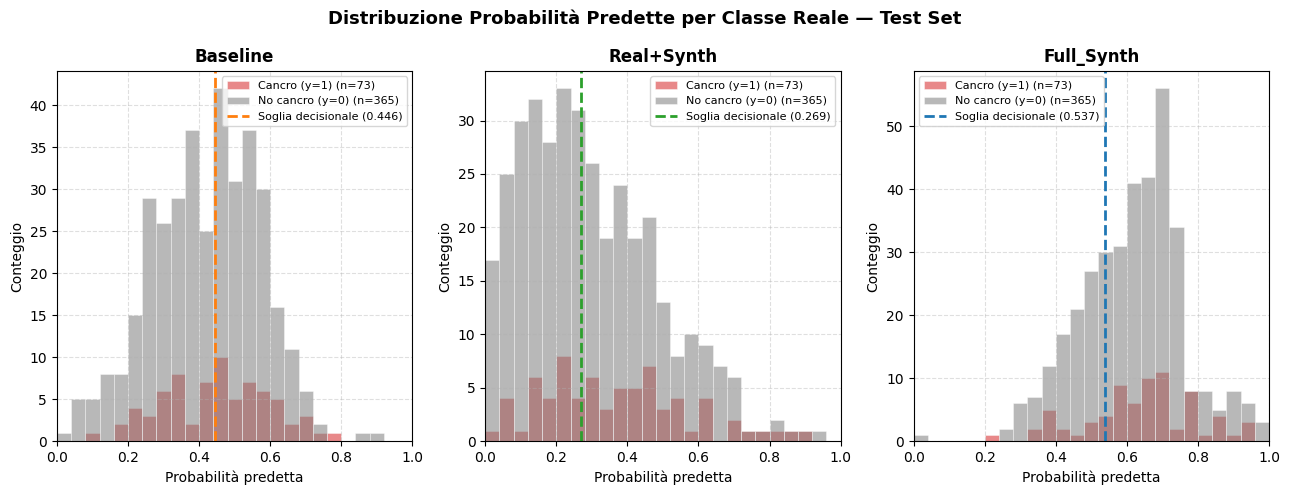

Salvato in: ../results/09_test_classificatori/figures/test_probability_distributions.png


In [61]:
COLORI_CLASSE    = {1: 'tab:red', 0: 'tab:gray'}
ETICHETTE_CLASSE = {1: 'Cancro (y=1)', 0: 'No cancro (y=0)'}
COLORS = {'Baseline': 'tab:orange', 'Real+Synth': 'tab:green', 'Full_Synth': 'tab:blue'}

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, (nome_conf, (probs, soglia)) in zip(axes, CLASSIFICATORI.items()):
    for classe in [1, 0]:
        maschera = (y_true == classe)
        prob_classe = probs[maschera]
        ax.hist(
            prob_classe,
            bins=25,
            range=(0, 1),
            alpha=0.55,
            color=COLORI_CLASSE[classe],
            label=f"{ETICHETTE_CLASSE[classe]} (n={int(maschera.sum())})",
            edgecolor='white',
            linewidth=0.5,
        )

    ax.axvline(
        x=soglia,
        color=COLORS[nome_conf],
        linestyle='--',
        linewidth=2,
        label=f'Soglia decisionale ({soglia:.3f})',
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probabilità predetta')
    ax.set_ylabel('Conteggio')
    ax.set_title(nome_conf, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Distribuzione Probabilità Predette per Classe Reale — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()

dist_path = os.path.join(FIGURES_DIR, 'test_probability_distributions.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {dist_path}")

#### Statistiche Distribuzione per Classe

Calcolo di media, deviazione standard, percentuale di campioni nella fascia centrale (incertezza sistematica) e percentuale di campioni overconfident nella direzione errata.

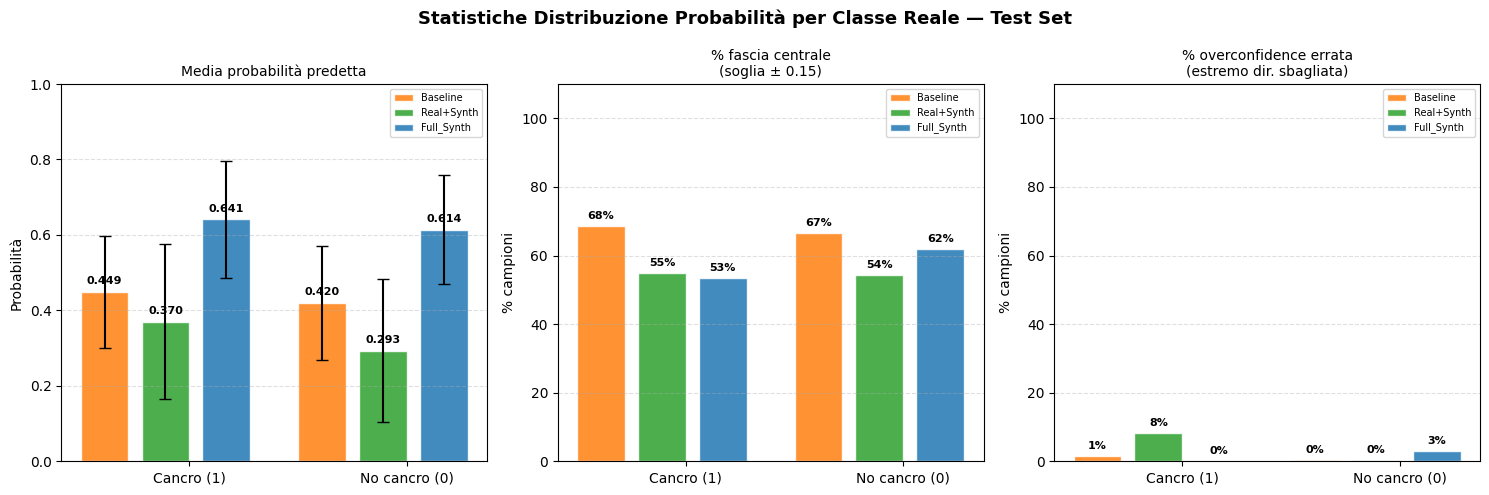

Figura salvata in:      ../results/09_test_classificatori/figures/test_probability_distribution_stats.png
Tabella CSV salvata in: ../results/09_test_classificatori/tables/test_probability_distribution_stats.csv


In [62]:
# Parametri per le statistiche di distribuzione
AMPIEZZA_FASCIA = 0.15   # fascia centrale: soglia ± AMPIEZZA_FASCIA
SOGLIA_ESTREMO  = 0.10   # estremi: prob < SOGLIA_ESTREMO o > (1 - SOGLIA_ESTREMO)

righe_stats = []

for nome_conf, (probs, soglia) in CLASSIFICATORI.items():
    for classe in [1, 0]:
        maschera = (y_true == classe)
        prob_classe = probs[maschera]
        n = int(maschera.sum())

        media = float(prob_classe.mean())
        std   = float(prob_classe.std())

        # Incertezza sistematica: campioni vicini alla soglia decisionale
        nella_fascia = (
            (prob_classe >= soglia - AMPIEZZA_FASCIA) &
            (prob_classe <= soglia + AMPIEZZA_FASCIA)
        )
        pct_fascia = round(100.0 * nella_fascia.sum() / n, 1)

        # Overconfidence nella direzione sbagliata:
        # classe cancro (1)    → prob < SOGLIA_ESTREMO   (sicuro: no-cancro, ma è cancro)
        # classe no-cancro (0) → prob > 1−SOGLIA_ESTREMO (sicuro: cancro,    ma è no-cancro)
        if classe == 1:
            errata = prob_classe < SOGLIA_ESTREMO
        else:
            errata = prob_classe > (1 - SOGLIA_ESTREMO)
        pct_overconfidence_errata = round(100.0 * errata.sum() / n, 1)

        righe_stats.append({
            'Modello':                   nome_conf,
            'Classe_reale':              'Cancro (1)' if classe == 1 else 'No cancro (0)',
            'N_campioni':                n,
            'Media_prob':                round(media, 4),
            'Std_prob':                  round(std, 4),
            'Pct_fascia_centrale':       pct_fascia,
            'Pct_overconfidence_errata': pct_overconfidence_errata,
        })

df_stats_prob = (
    pd.DataFrame(righe_stats)
    .set_index(['Modello', 'Classe_reale'])
)

stats_path = os.path.join(TABLES_DIR, 'test_probability_distribution_stats.csv')
df_stats_prob.to_csv(stats_path)

#  Visualizzazione Istogramma
classi_ordine = ['Cancro (1)', 'No cancro (0)']
x = np.arange(len(classi_ordine))
width = 0.22
step  = 0.28

metriche_grafici = [
    ('Media_prob',                'Media probabilità predetta',                          'Probabilità', (0, 1.0), False),
    ('Pct_fascia_centrale',       f'% fascia centrale\n(soglia ± {AMPIEZZA_FASCIA})',    '% campioni',  (0, 110), True),
    ('Pct_overconfidence_errata', f'% overconfidence errata\n(estremo dir. sbagliata)',  '% campioni',  (0, 110), True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metrica, titolo, ylabel, ylim, is_pct) in zip(axes, metriche_grafici):
    for i, (nome_conf, colore) in enumerate(COLORS.items()):
        valori = [df_stats_prob.loc[(nome_conf, cls), metrica] for cls in classi_ordine]
        errori = (
            [df_stats_prob.loc[(nome_conf, cls), 'Std_prob'] for cls in classi_ordine]
            if metrica == 'Media_prob' else None
        )
        bars = ax.bar(
            x + i * step, valori, width,
            label=nome_conf, color=colore, alpha=0.85, edgecolor='white',
            yerr=errori, capsize=4 if errori else 0,
            error_kw={'elinewidth': 1.5, 'ecolor': 'black'} if errori else {},
        )
        for bar, v in zip(bars, valori):
            etichetta = f'{v:.0f}%' if is_pct else f'{v:.3f}'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.015 if not is_pct else 1.5),
                    etichetta, ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x + step + width / 2)
    ax.set_xticklabels(classi_ordine)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(titolo, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Statistiche Distribuzione Probabilità per Classe Reale — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()

stats_fig_path = os.path.join(FIGURES_DIR, 'test_probability_distribution_stats.png')
fig.savefig(stats_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in:      {stats_fig_path}")
print(f"Tabella CSV salvata in: {stats_path}")

#### Grad-CAM — Esempi Qualitativi per Categoria

Per ciascun modello vengono selezionati 4 campioni rappresentativi lungo due assi:
- **Correttezza**: predizione corretta vs errata
- **Confidenza**: alta (massima distanza dalla soglia decisionale) vs bassa (minima distanza, caso "al limite")

Le combinazioni risultanti sono: Corretto/Alta confidenza, Corretto/Bassa confidenza, Sbagliato/Alta confidenza (overconfidence errata), Sbagliato/Bassa confidenza (errore di misura).

In [63]:
# Funzioni Grad-CAM

def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]
    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x
    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * IMAGENET_STD + IMAGENET_MEAN
    img_vis = np.clip(img_vis, 0, 1)[:, :, 0]
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title, fontsize=9, pad=6)
    ax.axis('off')

def carica_immagine_qualitativa(percorso):
    img_raw = tf.io.read_file(percorso)
    img = tf.image.decode_image(img_raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img

#### Preparazione Dati per Analisi Qualitativa

Per ciascun modello vengono calcolate la correttezza della predizione e la confidenza (distanza assoluta dalla soglia), usate per selezionare i campioni rappresentativi

In [64]:
df_predizioni['corretto_baseline'] = (
    df_predizioni['pred_baseline'] == df_predizioni['label_true']
)
df_predizioni['confidenza_baseline'] = (
    df_predizioni['prob_baseline'] - baseline_threshold
).abs()

df_predizioni['corretto_real_synth'] = (
    df_predizioni['pred_real_synth'] == df_predizioni['label_true']
)
df_predizioni['confidenza_real_synth'] = (
    df_predizioni['prob_real_synth'] - real_synth_threshold
).abs()

df_predizioni['corretto_full_synth'] = (
    df_predizioni['pred_full_synth'] == df_predizioni['label_true']
)
df_predizioni['confidenza_full_synth'] = (
    df_predizioni['prob_full_synth'] - full_synth_threshold
).abs()

# Configurazione 4 categorie: (chiave, corretto, strategia_confidenza, etichetta)

CATEGORIE_QUALITATIVE = [
    ('corretto_alta_conf',   True,  'max', 'Corretto — Alta confidenza'),
    ('corretto_bassa_conf',  True,  'min', 'Corretto — Bassa confidenza'),
    ('sbagliato_alta_conf',  False, 'max', 'Sbagliato — Alta confidenza'),
    ('sbagliato_bassa_conf', False, 'min', 'Sbagliato — Bassa confidenza'),
]

MODELLI_QUALITATIVE = {
    'Baseline': {
        'col_corretto':   'corretto_baseline',
        'col_confidenza': 'confidenza_baseline',
        'col_prob':       'prob_baseline',
        'col_pred':       'pred_baseline',
        'modello':        baseline_model,
    },
    'Real+Synth': {
        'col_corretto':   'corretto_real_synth',
        'col_confidenza': 'confidenza_real_synth',
        'col_prob':       'prob_real_synth',
        'col_pred':       'pred_real_synth',
        'modello':        real_synth_model,
    },
    'Full_Synth': {
        'col_corretto':   'corretto_full_synth',
        'col_confidenza': 'confidenza_full_synth',
        'col_prob':       'prob_full_synth',
        'col_pred':       'pred_full_synth',
        'modello':        full_synth_model,
    },
}

#### Selezione Campioni e Calcolo Heatmap

Per ciascuna combinazione modello × categoria viene selezionato un campione
(strategia `max`/`min` sulla confidenza) e calcolata la heatmap Grad-CAM

In [65]:
def seleziona_campione_qualitativo(df, col_corretto, col_confidenza, corretto, strategia):
    subset = df[df[col_corretto] == corretto]
    if subset.empty:
        return None
    idx = subset[col_confidenza].idxmax() if strategia == 'max' else subset[col_confidenza].idxmin()
    return df.loc[idx]

# Selezione campioni e generazione heatmap 
pannelli_qualitativi = {}
righe_tabella_esempi = []

for nome_modello, info in MODELLI_QUALITATIVE.items():
    for cat_key, corretto_cat, strategia_cat, etichetta_cat in CATEGORIE_QUALITATIVE:
        campione = seleziona_campione_qualitativo(
            df_predizioni,
            info['col_corretto'], info['col_confidenza'],
            corretto_cat, strategia_cat,
        )
        if campione is None:
            print(f"[{nome_modello}] Nessun campione disponibile per: {etichetta_cat}")
            pannelli_qualitativi[(nome_modello, cat_key)] = None
            continue

        img_tensor = carica_immagine_qualitativa(campione['processed_path'])
        heatmap    = make_gradcam_heatmap(tf.expand_dims(img_tensor, 0), info['modello'])

        etichetta_vera = 'Cancro'   if campione['label_true']         == 1 else 'No Cancro'
        predetta       = 'Cancro'   if campione[info['col_pred']]      == 1 else 'No Cancro'
        prob           = float(campione[info['col_prob']])
        confidenza     = float(campione[info['col_confidenza']])

        titolo = (
            f"{etichetta_cat}\n"
            f"Reale: {etichetta_vera}  →  {predetta} ({prob:.2f})\n"
            f"Conf: {confidenza:.3f}"
        )

        pannelli_qualitativi[(nome_modello, cat_key)] = {
            'img': img_tensor, 'heatmap': heatmap, 'titolo': titolo,
        }

        righe_tabella_esempi.append({
            'Modello':     nome_modello,
            'Categoria':   etichetta_cat,
            'Percorso':    campione['processed_path'],
            'Etichetta':   int(campione['label_true']),
            'Predizione':  int(campione[info['col_pred']]),
            'Probabilità': round(prob, 4),
            'Confidenza':  round(confidenza, 4),
        })

#### Visualizzazione Grad-CAM

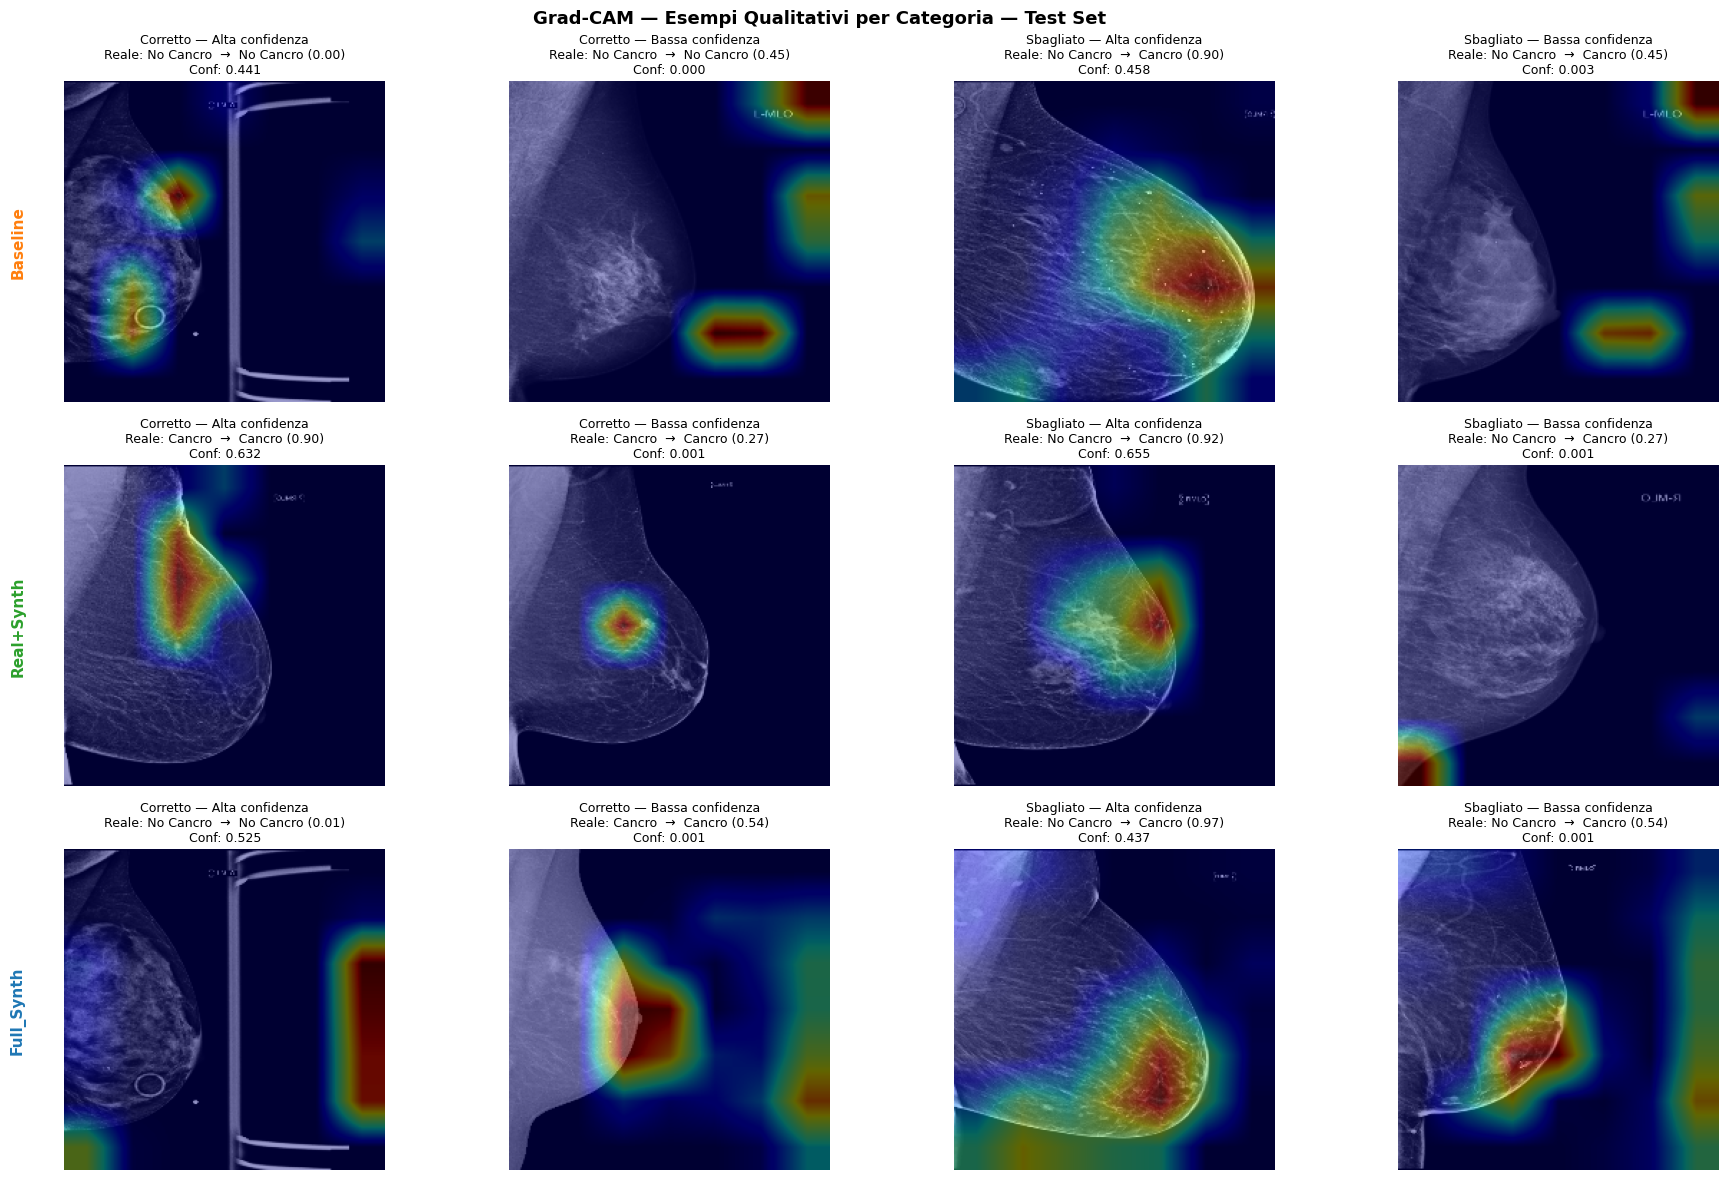

Figura salvata in: ../results/09_test_classificatori/figures/test_gradcam_esempi_qualitativi.png


In [66]:
# Figura: griglia 3 righe (modelli) × 4 colonne (categorie)
nomi_modelli_ord = list(MODELLI_QUALITATIVE.keys())
n_categorie = len(CATEGORIE_QUALITATIVE)

fig, axes = plt.subplots(3, n_categorie, figsize=(n_categorie * 5, 12))

for riga, nome_modello in enumerate(nomi_modelli_ord):
    for col, (cat_key, _, _, etichetta_cat) in enumerate(CATEGORIE_QUALITATIVE):
        ax = axes[riga, col]
        pannello = pannelli_qualitativi.get((nome_modello, cat_key))
        if pannello is None:
            ax.axis('off')
            ax.text(0.5, 0.5, f'{etichetta_cat}\n(nessun campione disponibile)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
        else:
            show_gradcam(pannello['img'], pannello['heatmap'], ax, title=pannello['titolo'])

    axes[riga, 0].text(
        -0.12, 0.5, nome_modello,
        transform=axes[riga, 0].transAxes,
        fontsize=11, fontweight='bold', color=COLORS[nome_modello],
        ha='right', va='center', rotation=90, clip_on=False,
    )

plt.suptitle('Grad-CAM — Esempi Qualitativi per Categoria — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(left=0.08)

gradcam_qual_path = os.path.join(FIGURES_DIR, 'test_gradcam_esempi_qualitativi.png')
fig.savefig(gradcam_qual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {gradcam_qual_path}")

#### Visualizzazione — ROC Curves a Confronto

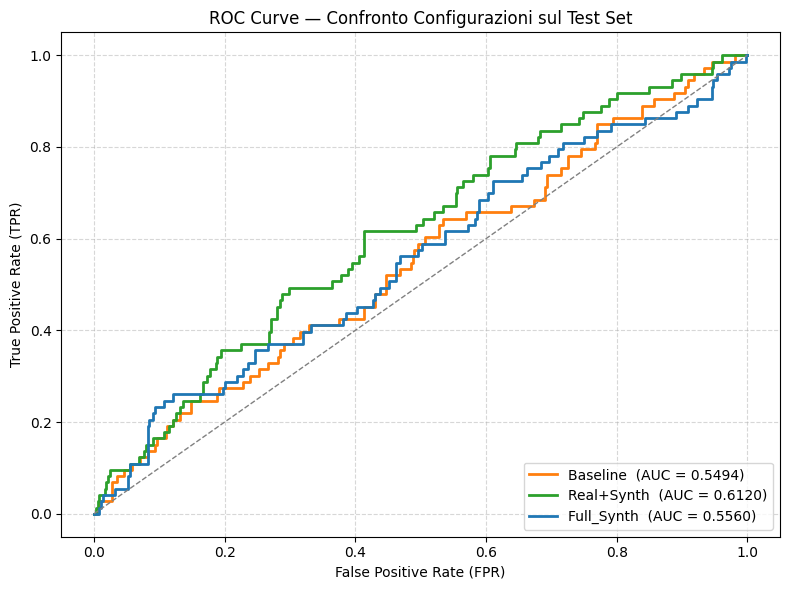

Salvato in: ../results/09_test_classificatori/figures/test_roc_curves.png


In [67]:
fig, ax = plt.subplots(figsize=(8, 6))
for nome_conf, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome_conf], lw=2,
            label=f"{nome_conf}  (AUC = {m['auc']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve — Confronto Configurazioni sul Test Set')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'test_roc_curves.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {roc_path}")

#### Precision-Recall Curve

Su dataset sbilanciati la PR curve è più informativa della ROC perché non viene gonfiata dalla numerosità dei negativi. La linea tratteggiata grigia rappresenta un classificatore casuale con la proporzione di positivi del test set.

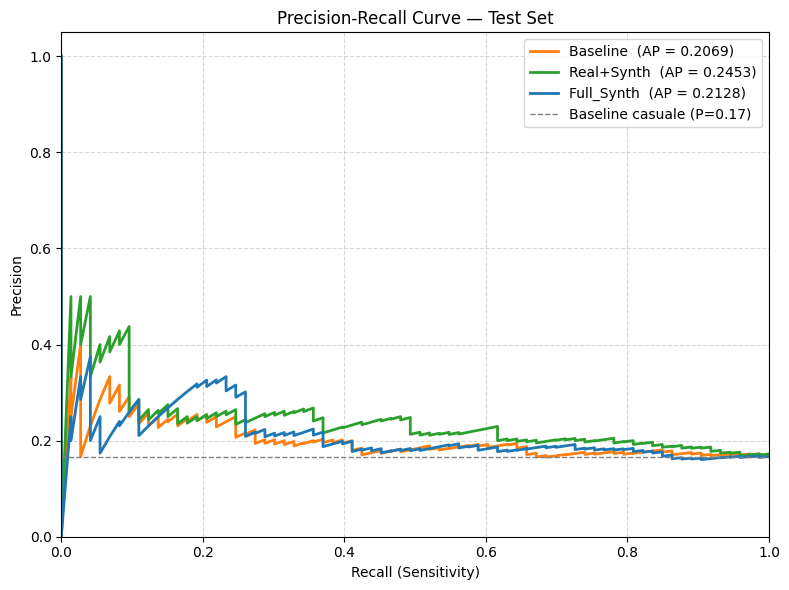

Salvato in: ../results/09_test_classificatori/figures/test_pr_curves.png


In [68]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

for nome_conf, (probs, _) in CLASSIFICATORI.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    ax.plot(recall_vals, precision_vals, lw=2,
            color=COLORS[nome_conf],
            label=f"{nome_conf}  (AP = {ap:.4f})")

baseline_pr = y_true.mean()
ax.axhline(y=baseline_pr, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline casuale (P={baseline_pr:.2f})')

ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Test Set')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()

pr_path = os.path.join(FIGURES_DIR, 'test_pr_curves.png')
fig.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvato in: {pr_path}')

#### Visualizzazione — Matrici di confusione

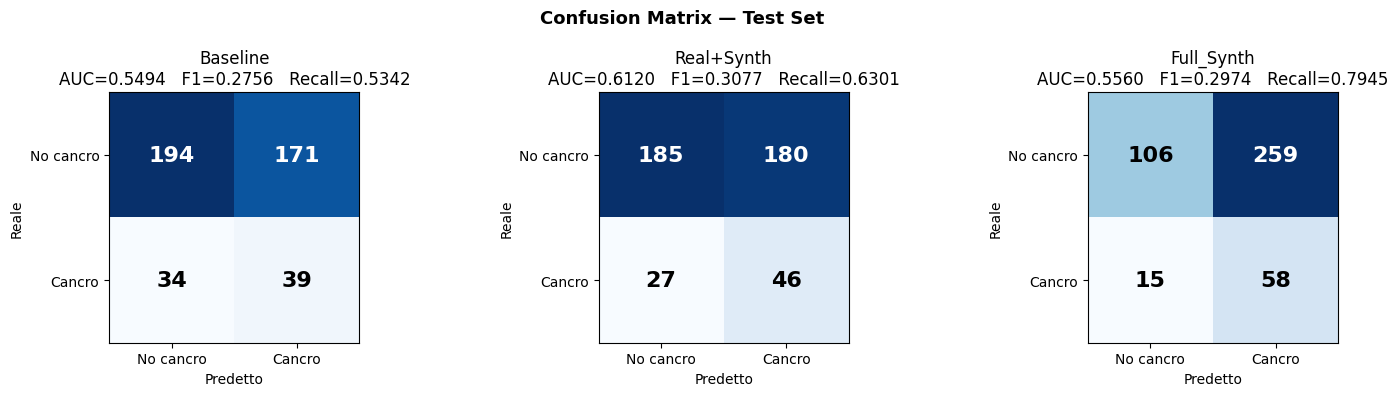

Salvato in: ../results/09_test_classificatori/figures/test_confusion_matrices.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nome_conf, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(y_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No cancro', 'Cancro'])
    ax.set_yticklabels(['No cancro', 'Cancro'])
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title(f'{nome_conf}\nAUC={m["auc"]:.4f}   F1={m["f1"]:.4f}   Recall={m["recall"]:.4f}')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, 'test_confusion_matrices.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {cm_path}")

#### Visualizzazione — Confronto Metriche

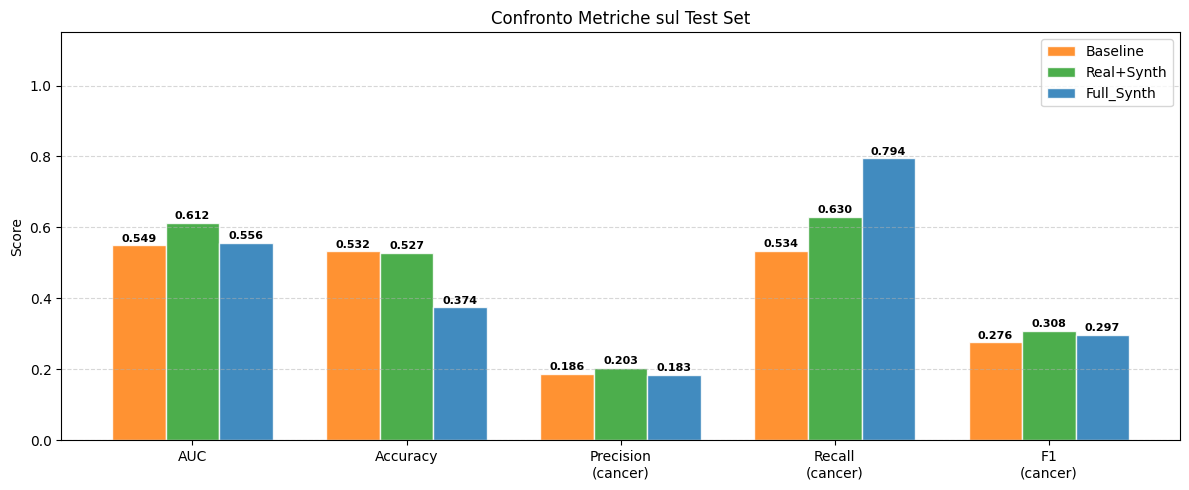

Salvato in: ../results/09_test_classificatori/figures/test_metrics_comparison.png


In [70]:
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(cancer)', 'Recall\n(cancer)', 'F1\n(cancer)']

x = np.arange(len(metric_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nome_conf, color) in enumerate(COLORS.items()):
    vals = [all_metrics[nome_conf][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome_conf,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Confronto Metriche sul Test Set')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'test_metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")